# Do the strong commodities keep winning? 🛢️🥇
### Commodity momentum — the textbook sort that backtests beautifully and still can't quite be certified

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Recent half: Not supported](https://img.shields.io/badge/Recent_half-Not_supported-8b949e?style=flat-square)

Here's a strategy straight out of the factor-investing textbook: once a month, rank a basket of commodities by how they did over the past year, **buy the top third** (the strong ones), **short the bottom third** (the weak ones), and hold for a month. Miffre & Rallis (2007) showed it paid handsomely in futures markets. Does it still work on stuff you could actually buy — a basket of commodity ETFs?

It backtests at **~+10%/yr**. And that number is more fragile than it looks.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 13 single-commodity ETFs, total-return, 2009→2026, 207 monthly rebalances. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from commodity_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    MRET = data.monthly_returns(PRICES)
else:
    PRICES = MRET = None
print("real cache present:", HAVE_REAL, "| monthly panel:",
      (None if MRET is None else f"{MRET.shape[0]} months x {MRET.shape[1]} ETFs"))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'ls_start': '2009-04-30', 'ls_end': '2026-06-30', 'n_months': 207, 'n_etfs': 13, 'panel_months': 220, 'mean_bps': 84.22, 'ann_pct': 10.11, 'hac_t': 1.655, 'hac_lags': 4, 'one_sample_t': 1.7, 'sharpe': 0.409, 'hit_pct': 54.6, 'turnover': 0.74, 'long_bps': 37.21, 'long_t': 1.33, 'short_bps': 47.01, 'short_t': 1.67, 'basket_ann': 3.29, 'placebo_seeds': 40, 'placebo_real_t': 1.655, 'placebo_mean_t': 0.108, 'placebo_sd_t': 0.913, 'placebo_mean_sharpe': 0.021, 'placebo_frac_ge2': 0.0, 'placebo_p': 0.025, 'era_split': '2019-01-01', 'early_n': 117, 'early_bps': 119.0, 'early_t': 2.27, 'early_sharpe': 0.64, 'late_n': 90, 'late_bps': 39.0, 'late_t': 0.43, 'late_sharpe': 0.17, 'diff_t': -0.78, 'timer5_gross': 10.11, 'timer5_net': 9.16, 'timer5_t': 1.5, 'timer5_sharpe': 0.37, 'timer10_gross': 10.11, 'timer10_net': 8.72, 'timer10_t': 1.42, 'timer10_sharpe': 0.35, 'syn_null_mean': -0.0, 'syn_null_sd': 1.35, 'syn_null_fire': 2, 'syn_planted_t': 13.34, 'syn_planted_bps': 800.16, 'syn_planted_sharpe': 5.21, 'fp': '1c68bd1531bb'}


real cache present: True | monthly panel: 220 months x 13 ETFs


## The answer first

| Question | Answer |
|---|---|
| Does buying strong commodities and shorting weak ones pay? | **On paper, yes — about +10%/yr** (Sharpe 0.41). But the honest statistical test comes up just short: it's *probably* real, not *provably* real. |
| Is it just luck / a random sort? | **No.** A random ranking of the same commodities almost never does this well — so the momentum ranking really is picking up something. |
| Does it still work lately? | **Not really.** Almost the entire edge is from **2009-2018**. Since 2019 it's been essentially flat. |
| Do trading costs kill it? | **Surprisingly, no.** You only rebalance monthly, so costs shave off very little — net is still ~+9%/yr. What undercuts it is the shaky *t*-stat and the dead recent decade, not costs. |

> A great-looking backtest that the statistics can't quite sign off on — and that stopped paying about the time everyone had heard of it.

## 1 · The claim

> *"Commodities trend. The ones that led the pack over the last year tend to keep leading; the laggards keep lagging. So rank them, go long the leaders and short the laggards, and rebalance monthly."*

This is **momentum** — the same 'buy past winners' idea that's famous in stocks (Jegadeesh-Titman 1993), here applied *across* commodities. Miffre & Rallis (2007) documented it in commodity futures; we test the version a real investor could hold: a basket of single-commodity **ETFs** (gold, silver, copper, crude, natural gas, corn, wheat, sugar, …).

## 2 · So what?

If real, this is a clean, mechanical, once-a-month rule with no forecasting: just sort and hold. It's also one of the most-cited 'alternative' return sources — the kind of thing that ends up inside managed-futures funds and 'liquid alt' products. So it's worth checking whether the free, investable version actually delivers, or whether — like a lot of published factors — it looked great in-sample and quietly faded once the paper was out.

## 3 · How would we even know?

- **The sort.** Each month, rank the 13 ETFs by their trailing 12-month return (skipping the most recent month), long the top third, short the bottom third.
- **The *t*-test.** Is the average monthly profit big enough, relative to its wobble, to be real? (We use a stat that accounts for months bunching together.)
- **The luck check.** Rank the commodities *randomly* instead, hundreds of times — does the real momentum ranking beat the coin-flip rankings?
- **The 'still working?' check.** Split the history in half and look at the recent decade on its own.
- **The trade check.** Charge realistic costs and short-borrow — does the net survive?

## 4 · The teardown — let's actually look

**First, the equity curve.** One dollar in the long/short momentum book.

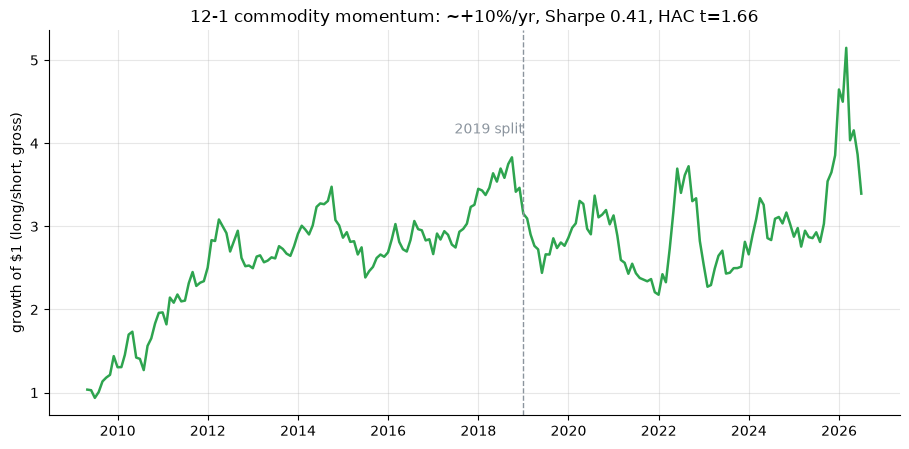

gross ~+10.11%/yr | Sharpe 0.41 | HAC t +1.66 (bar is 2)


In [2]:
if HAVE_REAL:
    rep = st.momentum_report(MRET)
    ret = rep['ret']
    ann, shp, t = rep['ann_pct'], rep['sharpe'], rep['hac_t']
else:
    ret = None; ann, shp, t = R['ann_pct'], R['sharpe'], R['hac_t']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
if ret is not None:
    eq = (1 + ret).cumprod()
    ax.plot(eq.index, eq.values, color=GREEN, lw=1.8)
    ax.axvline(pd.Timestamp(R['era_split']), ls='--', c=GREY, lw=1)
    ax.annotate('2019 split', (pd.Timestamp(R['era_split']), eq.max()*0.8),
                color=GREY, ha='right')
ax.set_ylabel('growth of $1 (long/short, gross)')
ax.set_title(f'12-1 commodity momentum: ~{ann:+.0f}%/yr, Sharpe {shp:.2f}, HAC t={t:.2f}')
plt.tight_layout(); plt.show()
print(f'gross ~{ann:+.2f}%/yr | Sharpe {shp:.2f} | HAC t {t:+.2f} (bar is 2)')

A smooth-ish climb to **~+10%/yr** at Sharpe **0.41** — the kind of curve that sells a strategy. But look where it climbs: most of the gain is **before the 2019 dashed line**. After it, the curve mostly goes sideways.

**Is the sort actually skillful, or just lucky?** We rank the same commodities *randomly* 40 times and compare.

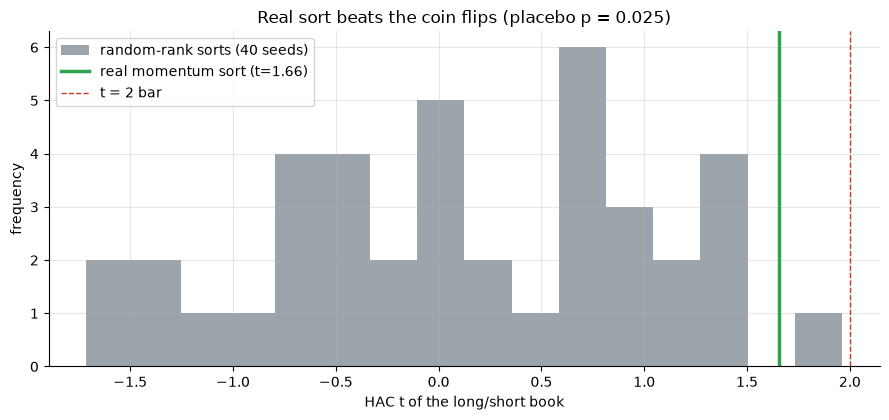

real t +1.66 vs random-rank mean +0.11; p = 0.025; but real t is still under the t=2 bar


In [3]:
if HAVE_REAL:
    pl = st.random_placebo(MRET)
    real_t, ts = pl['real_t'], pl['ts']
else:
    real_t = R['hac_t']
    ts = np.random.default_rng(792).normal(R['placebo_mean_t'], R['placebo_sd_t'], 40)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(ts, bins=16, color=GREY, alpha=.85, label='random-rank sorts (40 seeds)')
ax.axvline(real_t, c=GREEN, lw=2.5, label=f'real momentum sort (t={real_t:.2f})')
ax.axvline(2, ls='--', c=RED, lw=1, label='t = 2 bar')
ax.set_xlabel('HAC t of the long/short book'); ax.set_ylabel('frequency')
ax.set_title(f"Real sort beats the coin flips (placebo p = {R['placebo_p']:.3f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"real t {real_t:+.2f} vs random-rank mean {R['placebo_mean_t']:+.2f}; "
      f"p = {R['placebo_p']:.3f}; but real t is still under the t=2 bar")

The real momentum sort (green) sits well to the right of the random-rank cloud — **p = 0.025**, so it genuinely isn't a coin flip. But notice the green line still lands *short of the red t = 2 bar*. It beats random, yet doesn't clear the desk's certification threshold. That tension is the whole story.

**Does it still work lately?**

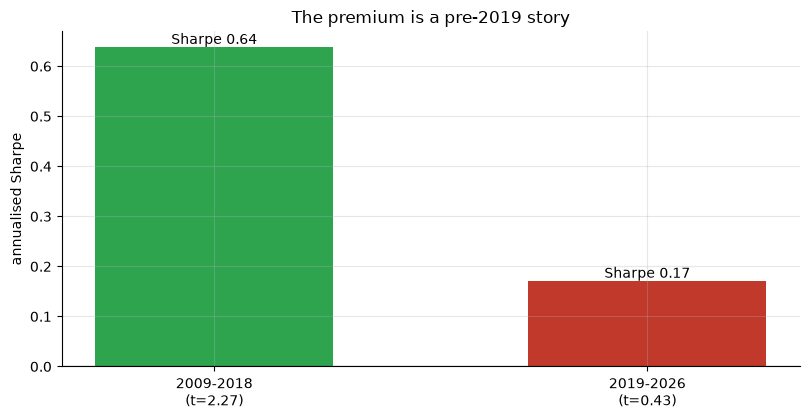

early Sharpe 0.64 (t=+2.27) | late Sharpe 0.17 (t=+0.43)


In [4]:
if HAVE_REAL:
    sp = st.subperiod_contrast(MRET, data.ERA_SPLIT)
    e_s, l_s = sp['early_sharpe'], sp['late_sharpe']
    e_t, l_t = sp['early_t'], sp['late_t']
else:
    e_s, l_s = R['early_sharpe'], R['late_sharpe']
    e_t, l_t = R['early_t'], R['late_t']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['2009-2018\n(t={:.2f})'.format(e_t),'2019-2026\n(t={:.2f})'.format(l_t)],
       [e_s, l_s], color=[GREEN, RED], width=.55)
for i,v in enumerate([e_s, l_s]): ax.annotate(f'Sharpe {v:.2f}',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annualised Sharpe')
ax.set_title('The premium is a pre-2019 story')
plt.tight_layout(); plt.show()
print(f'early Sharpe {e_s:.2f} (t={e_t:+.2f}) | late Sharpe {l_s:.2f} (t={l_t:+.2f})')

The first half clears the bar on its own (Sharpe 0.64, t = 2.27); the second half is basically flat (Sharpe 0.17, t = 0.43). This is the well-known post-2015 fade of commodity factors — the effect that made the paper famous seems to have thinned out about the time everyone piled in. *(One honest caveat: seven years isn't enough data to *prove* it died — but it certainly hasn't been paying.)*

**Finally, the trade — do costs matter here?**

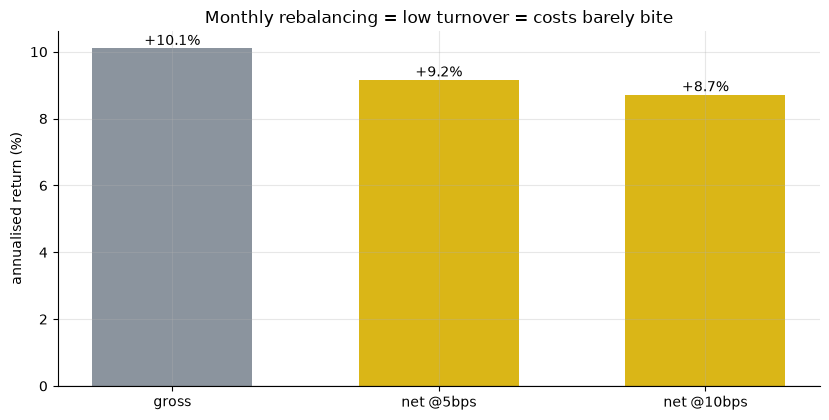

gross +10.1% -> net +9.2% (5bps) / +8.7% (10bps)


In [5]:
if HAVE_REAL:
    tm5 = st.costed_timer(MRET, cost_bps=5.0)
    tm10 = st.costed_timer(MRET, cost_bps=10.0)
    g, n5, n10 = tm5['gross_ann_pct'], tm5['net_ann_pct'], tm10['net_ann_pct']
else:
    g, n5, n10 = R['timer5_gross'], R['timer5_net'], R['timer10_net']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['gross','net @5bps','net @10bps'], [g, n5, n10], color=[GREY, AMBER, AMBER], width=.6)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annualised return (%)')
ax.set_title('Monthly rebalancing = low turnover = costs barely bite')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}% -> net {n5:+.1f}% (5bps) / {n10:+.1f}% (10bps)')

Because you only trade once a month, costs shave the gross **+10%/yr** down to only **+9%/yr** even at a chunky 10 bps a side plus short-borrow. So — unusually for this desk — **costs are not the thing that kills it.** The thing that kills it is that the *t*-stat never cleared the bar, the whole premium is pre-2019, and the basket is a tiny 13-name set of *survivors* (funds that lived — a mild upward bias baked in). Real-*looking*, not certifiable, and not paying lately.

## 5 · The verdict

- **Signal — Weak.** +10%/yr at Sharpe 0.41 and clearly better than random (p = 0.025), but the robust *t* is only 1.66 — under the bar. Real in the literature; this tape can't certify it.
- **Tradability — Fragile.** Costs barely dent it, but the net *t* is uncertified, the edge is all pre-2019, and it's a 13-name survivor basket. Survives on paper, not investable at scale.
- **"Still working lately?" — Not supported.** The 2019-2026 half is flat (t = 0.43). The premium was a pre-2019 phenomenon.

## 6 · Going further 🚪

- **Why commodities trend at all:** supply is slow to adjust (you can't build a mine or plant a crop overnight), so shocks persist — a plausible economic root for momentum that stocks don't share.
- **Why it may have faded:** once managed-futures funds industrialised the trade post-2008, the easy premium got competed down — a recurring pattern for published factors.
- **Sibling studies:** [507-cross-sectional-momentum](../../507-cross-sectional-momentum/) runs the *same* sort on **equities** (verdict `NONE`); [638-value-momentum-everywhere](../../638-value-momentum-everywhere/) blends momentum *and* value across four asset classes; the single-commodity **seasonality** studies (226, 307, 648-651) test *calendar* effects, not cross-sectional strength. See [docs/references.md](../docs/references.md) for the exact dedup.

*Think a bigger basket or a longer-history futures tape revives it? Show a net, certifiable (HAC t ≥ 2) edge on the recent decade — then we'll talk.*